In [1]:
import numpy as np
import mdtraj as md
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import align, rms
from MDAnalysis import transformations as trans
import pymbar.timeseries as timeseries
import MDAnalysis.analysis.dihedrals as dihedrals
import seaborn as sns

/apps/gent/RHEL9/cascadelake-ib/software/Biopython/1.85-foss-2025a/lib/python3.13/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


ModuleNotFoundError: No module named 'pymbar'

In [2]:
files_BDQ= [("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_1/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_1/topol.xtc"),
        ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_2/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_2/topol.xtc"),
        ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_3/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_3/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_4/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_4/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_5/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_5/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_6/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_6/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_7/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_7/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_8/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_8/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_9/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_9/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_10/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_10/topol.xtc"),]

In [3]:
files_BDN= [("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_1/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_1/topol.xtc"),
        ("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_2/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_2/topol.xtc"),
        ("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_3/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_3/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_4/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_4/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_5/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_5/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_6/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_6/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_7/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_7/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_8/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_8/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_9/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_9/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_10/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_10/topol.xtc"),]

In [4]:
def get_com(u, sel: str, sel2: str):
    com_arr = np.empty((u.trajectory.n_frames, 3))
    select_group1 = u.select_atoms(sel)
    select_group2 = u.select_atoms(sel2)
    for frame in u.trajectory:
        if not frame.frame %10:
            print(frame.frame)
        com_arr[frame.frame, :] = select_group1.center_of_mass(unwrap=True)-select_group2.center_of_mass() # remove PBCs
    return com_arr

In [5]:
BDQ_com_all_reps = np.empty((10, 101, 3))

for i, simulation in enumerate(files_BDQ):
    topology, trajectory = simulation
    u = mda.Universe(topology, trajectory)
    print(u.trajectory)
    BDQ_com_all_reps[i, :, :] = get_com(u, sel = "resname BDQ", sel2 = "resname POPE")

<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_1/topol.xtc with 101 frames of 43975 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_2/topol.xtc with 101 frames of 43975 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_3/topol.xtc with 101 frames of 43975 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_4/topol.xtc with 101 frames of 43975 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_5/topol.xtc with 101 frames of 43975 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_

In [6]:
BDN_com_all_reps = np.empty((10, 101, 3))

for i, simulation in enumerate(files_BDN):
    topology, trajectory = simulation
    u = mda.Universe(topology, trajectory)
    print(u.trajectory)
    BDN_com_all_reps[i, :, :] = get_com(u, sel = "resname BDN", sel2 = "resname POPE")

<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_1/topol.xtc with 101 frames of 43973 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_2/topol.xtc with 101 frames of 43973 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_3/topol.xtc with 101 frames of 43973 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_4/topol.xtc with 101 frames of 43973 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_5/topol.xtc with 101 frames of 43973 atoms>
0
10
20
30
40
50
60
70
80
90
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/memb_bdq/Equil/TPS/production_replicates/rep_6/topol.xtc with 101 frames of 43973 atoms>
0

In [9]:
phosphoethanolamine = np.loadtxt("../phosphoethanolamine_density.xvg", comments=["#", "@"])
glycerol = np.loadtxt("../glycerol.xvg", comments=["#", "@"])
tails = np.loadtxt("../tails.xvg", comments=["#", "@"])
water = np.loadtxt("/scratch/gent/vo/000/gvo00003/vsc48847/apo_protein/charmm-gui-7064934746/gromacs/Rep1/water.xvg", comments=["#", "@"])

In [15]:
import numpy as np
import matplotlib.pyplot as plt

names = ["Phosphoethanolamine", "Glycerol", "acyl", "water"]
lipidcolors = ["tomato", "green", "grey", "dodgerblue"]

fig, ax = plt.subplots(
    1, 3,
    figsize=(12, 4),
    width_ratios=[3, 3, 1]
)

# Kleuren voor replicates
rep_colors = plt.cm.viridis(np.linspace(0, 1, 10))

# ----------------
# BDN TPS (links)
# ----------------
for i in range(10):
    ax[0].plot(
        BDN_com_all_reps[i, :, 2] / 10,
        linestyle='-',
        linewidth=1,
        color=rep_colors[i]
    )

# ----------------
# BDP TPS (rechts)
# ----------------
for i in range(10):
    ax[1].plot(
        BDQ_com_all_reps[i, :, 2] / 10,
        linestyle='-',
        linewidth=1,
        color=rep_colors[i],
        label=f"replicate {i+1}"
    )

# ----------------
# Lipid density
# ----------------
for i, group in enumerate((phosphoethanolamine, glycerol, tails, water)):
    ax[2].plot(
        group[:, 1],
        group[:, 0] - np.mean(group[:, 0]),
        label=names[i],
        color=lipidcolors[i]
    )

# ----------------
# Axis instellingen
# ----------------
for a in ax:
    a.set_ylim(-2, 2)
    a.spines[['right', 'top']].set_visible(False)

ax[0].axhline(0, color='black', linestyle='--', linewidth=1)
ax[1].axhline(0, color='black', linestyle='--', linewidth=1)

ax[0].set_title("BDN")
ax[1].set_title("BDP")

ax[0].set_xlabel("Frame")
ax[1].set_xlabel("Frame")
ax[2].set_xlabel("Density (kg/m$^{-3}$)")
ax[0].set_ylabel("Z axis position (nm)")

# Frame → time labels
ticks = np.arange(0, 101, 20)
labels = np.arange(0, 501, 100)

ax[0].set_xticks(ticks, labels)
ax[1].set_xticks(ticks, labels)

# ----------------
# Legends
# ----------------
ax[1].legend(
    loc='lower center',
    bbox_to_anchor=(0, -0.675),
    ncol=2,
    frameon=False
)

ax[2].legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.675),
    frameon=False
)

# Layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.35)

plt.savefig("TPS.png", dpi=300)
plt.show()

In [9]:
umbrella= [("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/umbrella/membrane_bdq_us-1.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/umbrella/us-1.xtc")]
BDN_com_all_reps = np.empty((1, 201, 3))

for i, simulation in enumerate(umbrella):
    topology, trajectory = simulation
    u = mda.Universe(topology, trajectory)
    print(u.trajectory)
    BDN_com_all_reps[i, :, :] = get_com(u, sel = "resname BDQ", sel2 = "resname POPE")

<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/umbrella/us-1.xtc with 201 frames of 43975 atoms>
0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200


ValueError: The number of FixedLocator locations (6), usually from a call to set_ticks, does not match the number of labels (11).

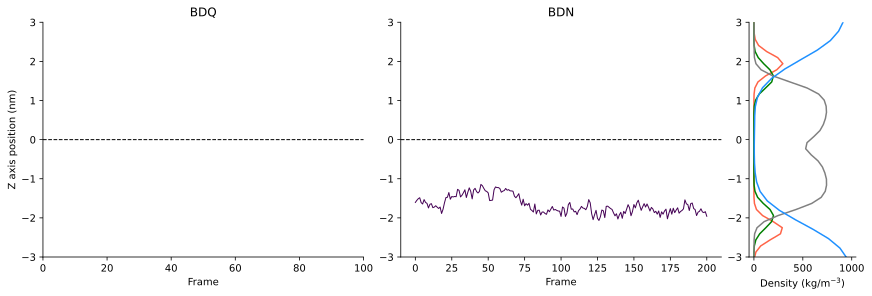

In [15]:
import numpy as np
import matplotlib.pyplot as plt

names = ["Phosphoethanolamine", "Glycerol", "acyl", "water"]
lipidcolors = ["tomato", "green", "grey", "dodgerblue"]

fig, ax = plt.subplots(
    1, 3,
    figsize=(12,4),
    width_ratios=[3,3,1]
)

# Zelfde kleuren voor BDQ en BDN replicates
rep_colors = plt.cm.viridis(np.linspace(0,1,10))

# ----------------
# BDN TPS
# ----------------
for i in range(1):
    ax[1].plot(
        BDN_com_all_reps[i,:,2] / 10,
        linestyle='-',
        linewidth=1,
        color=rep_colors[i]
    )

    

# ----------------
# Lipid density
# ----------------
for i, group in enumerate((phosphoethanolamine, glycerol, tails, water)):
    ax[2].plot(
        group[:,1],
        group[:,0] - np.mean(group[:,0]),
        label=names[i],
        color=lipidcolors[i]
    )

# ----------------
# Axis instellingen
# ----------------
for a in ax:
    a.set_ylim(-3,3)
    a.spines[['right','top']].set_visible(False)

ax[0].axhline(0, color='black', linestyle='--', linewidth=1)
ax[1].axhline(0, color='black', linestyle='--', linewidth=1)

ax[0].set_title("BDQ")
ax[1].set_title("BDN")

ax[0].set_xlabel("Frame")
ax[1].set_xlabel("Frame")
ax[2].set_xlabel("Density (kg/m$^{-3}$)")

ax[0].set_ylabel("Z axis position (nm)")

# Frame → time labels
ticks = np.arange(0,101,20)
labels = np.arange(0,1001,100)

ax[0].set_xticks(ticks, labels)
ax[1].set_xticks(ticks, labels)

# ----------------
# Legends
# ----------------
# BDQ replicates legend iets naar rechts (tussen BDQ en BDN)
ax[0].legend(
    loc='lower center',
    bbox_to_anchor=(0.9,-0.675),  # x verschoven naar rechts
    ncol=2,
    frameon=False
)

# Lipid legend blijft zoals voorheen
ax[2].legend(
    loc='lower center',
    bbox_to_anchor=(0.5,-0.675),
    frameon=False
)

# Layout aanpassen zodat x-as leesbaar blijft
plt.tight_layout()
plt.subplots_adjust(bottom=0.35)

plt.show()